# Lab 7: Decision Tree Classification

**Student**: 2547246  
**Subject**: Machine Learning Lab  
**Trimester**: IV

---

## Aim
To implement a Decision Tree classifier on a binary medical dataset, visualize the learned decision tree, and evaluate the model using various metrics including accuracy, confusion matrix, and ROC-AUC curve.

## Objectives
1. Generate and explore a binary classification dataset (Tumor: Benign vs Malignant)
2. Preprocess the data with train-test split
3. Train a Decision Tree classifier using Gini impurity criterion
4. Visualize the decision tree structure
5. Analyze feature importances
6. Evaluate using Accuracy, Classification Report, Confusion Matrix, and ROC Curve
7. Visualize the decision boundary

In [1]:
# ============================================================
# Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, auc
)

# Style settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Section 1: Load & Explore Dataset

In [2]:
# Load dataset
df = pd.read_csv('tumor_dataset.csv')

print('=== Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'\nColumn names: {df.columns.tolist()}')
print(f'\nClass distribution:\n{df["diagnosis"].value_counts()}')
print('\n=== First 5 rows ===')
display(df.head())
print('\n=== Statistical Summary ===')
display(df.describe().round(3))

=== Dataset Overview ===
Shape: (500, 7)

Column names: ['radius', 'texture', 'perimeter', 'smoothness', 'compactness', 'symmetry', 'diagnosis']

Class distribution:
diagnosis
Malignant    256
Benign       244
Name: count, dtype: int64

=== First 5 rows ===


,radius,texture,perimeter,smoothness,compactness,symmetry,diagnosis
0,14.68,23.19,121.58,0.13,0.24,0.20,Malignant
1,16.46,22.53,92.46,0.15,0.17,0.15,Benign
2,15.87,22.91,96.83,0.13,0.17,0.20,Benign
3,13.25,16.76,103.37,0.10,0.20,0.21,Benign
4,14.69,18.07,99.08,0.14,0.23,0.19,Malignant



=== Statistical Summary ===


,radius,texture,perimeter,smoothness,compactness,symmetry
count,500.000,500.000,500.000,500.000,500.000,500.000
mean,14.679,19.400,98.895,0.125,0.193,0.192
std,1.329,3.169,11.304,0.022,0.045,0.036
min,10.000,10.000,65.000,0.050,0.050,0.100
25%,13.910,17.418,91.242,0.110,0.170,0.160
50%,14.635,19.500,98.750,0.130,0.190,0.190
75%,15.302,21.452,106.112,0.140,0.220,0.220
max,20.000,30.000,140.000,0.200,0.350,0.300


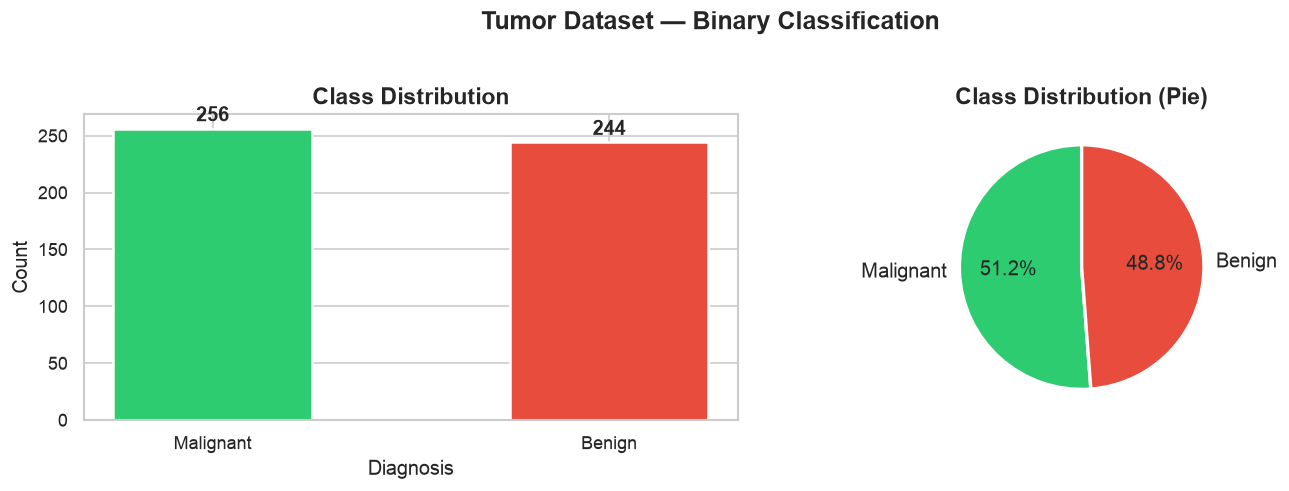

Class distribution chart saved.


In [3]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['diagnosis'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            textprops={'fontsize': 12},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')

plt.suptitle('Tumor Dataset — Binary Classification', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Class distribution chart saved.')

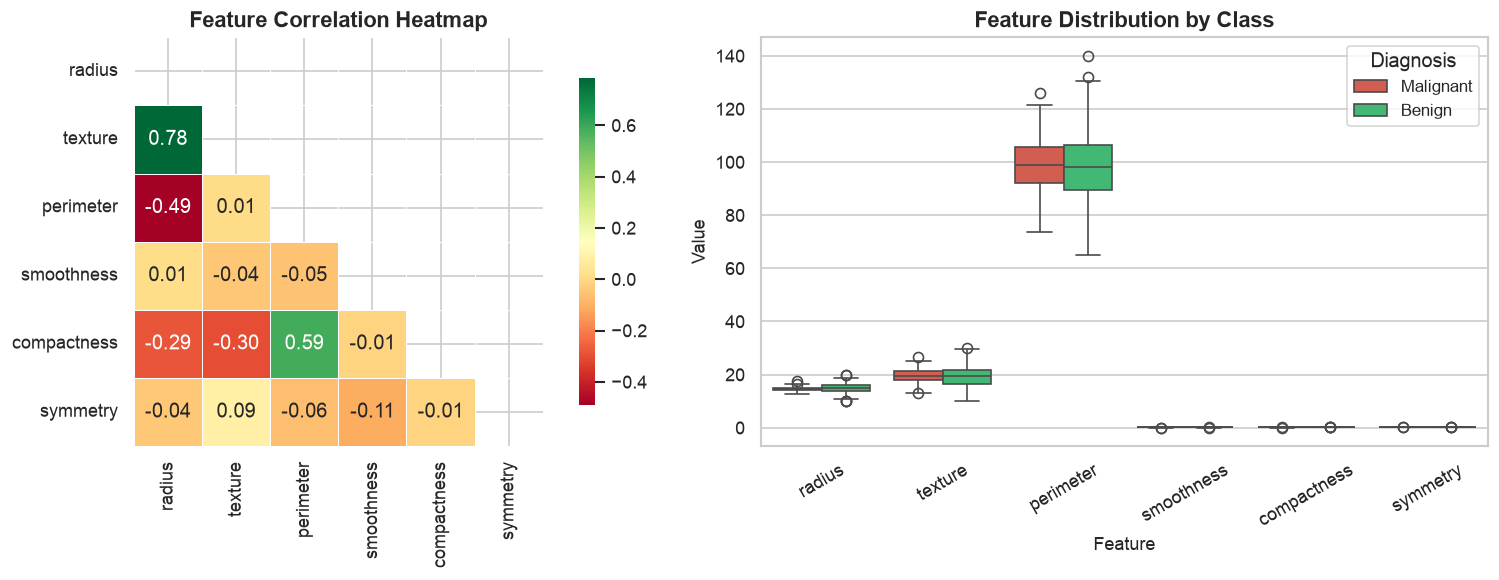

Feature exploration chart saved.


In [4]:
# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
numeric_cols = ['radius', 'texture', 'perimeter', 'smoothness', 'compactness', 'symmetry']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Boxplot of features by class
df_melt = df.melt(id_vars='diagnosis', value_vars=numeric_cols,
                   var_name='Feature', value_name='Value')
sns.boxplot(data=df_melt, x='Feature', y='Value', hue='diagnosis',
            palette={'Benign': '#2ecc71', 'Malignant': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Feature Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature', fontsize=11)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Diagnosis', fontsize=10)

plt.tight_layout()
plt.savefig('feature_exploration.png', bbox_inches='tight', dpi=150)
plt.show()
print('Feature exploration chart saved.')

---
## Section 2: Data Preprocessing

In [5]:
# Encode target label
le = LabelEncoder()
df['label'] = le.fit_transform(df['diagnosis'])  # Benign=0, Malignant=1

feature_names = ['radius', 'texture', 'perimeter', 'smoothness', 'compactness', 'symmetry']
X = df[feature_names].values
y = df['label'].values
class_names = le.classes_.tolist()

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size      : {X_test.shape[0]} samples')
print(f'Features           : {feature_names}')
print(f'Class mapping      : {dict(zip(range(len(class_names)), class_names))}')

Training set size : 400 samples
Test set size      : 100 samples
Features           : ['radius', 'texture', 'perimeter', 'smoothness', 'compactness', 'symmetry']
Class mapping      : {0: 'Benign', 1: 'Malignant'}


---
## Section 3: Train Decision Tree Classifier

In [6]:
# Train Decision Tree
clf = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f'Decision Tree trained successfully!')
print(f'\nHyperparameters:')
print(f'  criterion      = gini')
print(f'  max_depth      = 4')
print(f'  min_samples_split = 10')
print(f'  min_samples_leaf  = 5')
print(f'\nTraining Accuracy : {accuracy_score(y_train, clf.predict(X_train)):.4f}')
print(f'Test Accuracy     : {acc:.4f}')
print(f'Tree Depth        : {clf.get_depth()}')
print(f'Number of Leaves  : {clf.get_n_leaves()}')

Decision Tree trained successfully!

Hyperparameters:
  criterion      = gini
  max_depth      = 4
  min_samples_split = 10
  min_samples_leaf  = 5

Training Accuracy : 0.9175
Test Accuracy     : 0.8200
Tree Depth        : 4
Number of Leaves  : 12


---
## Section 4: Visualize Decision Tree

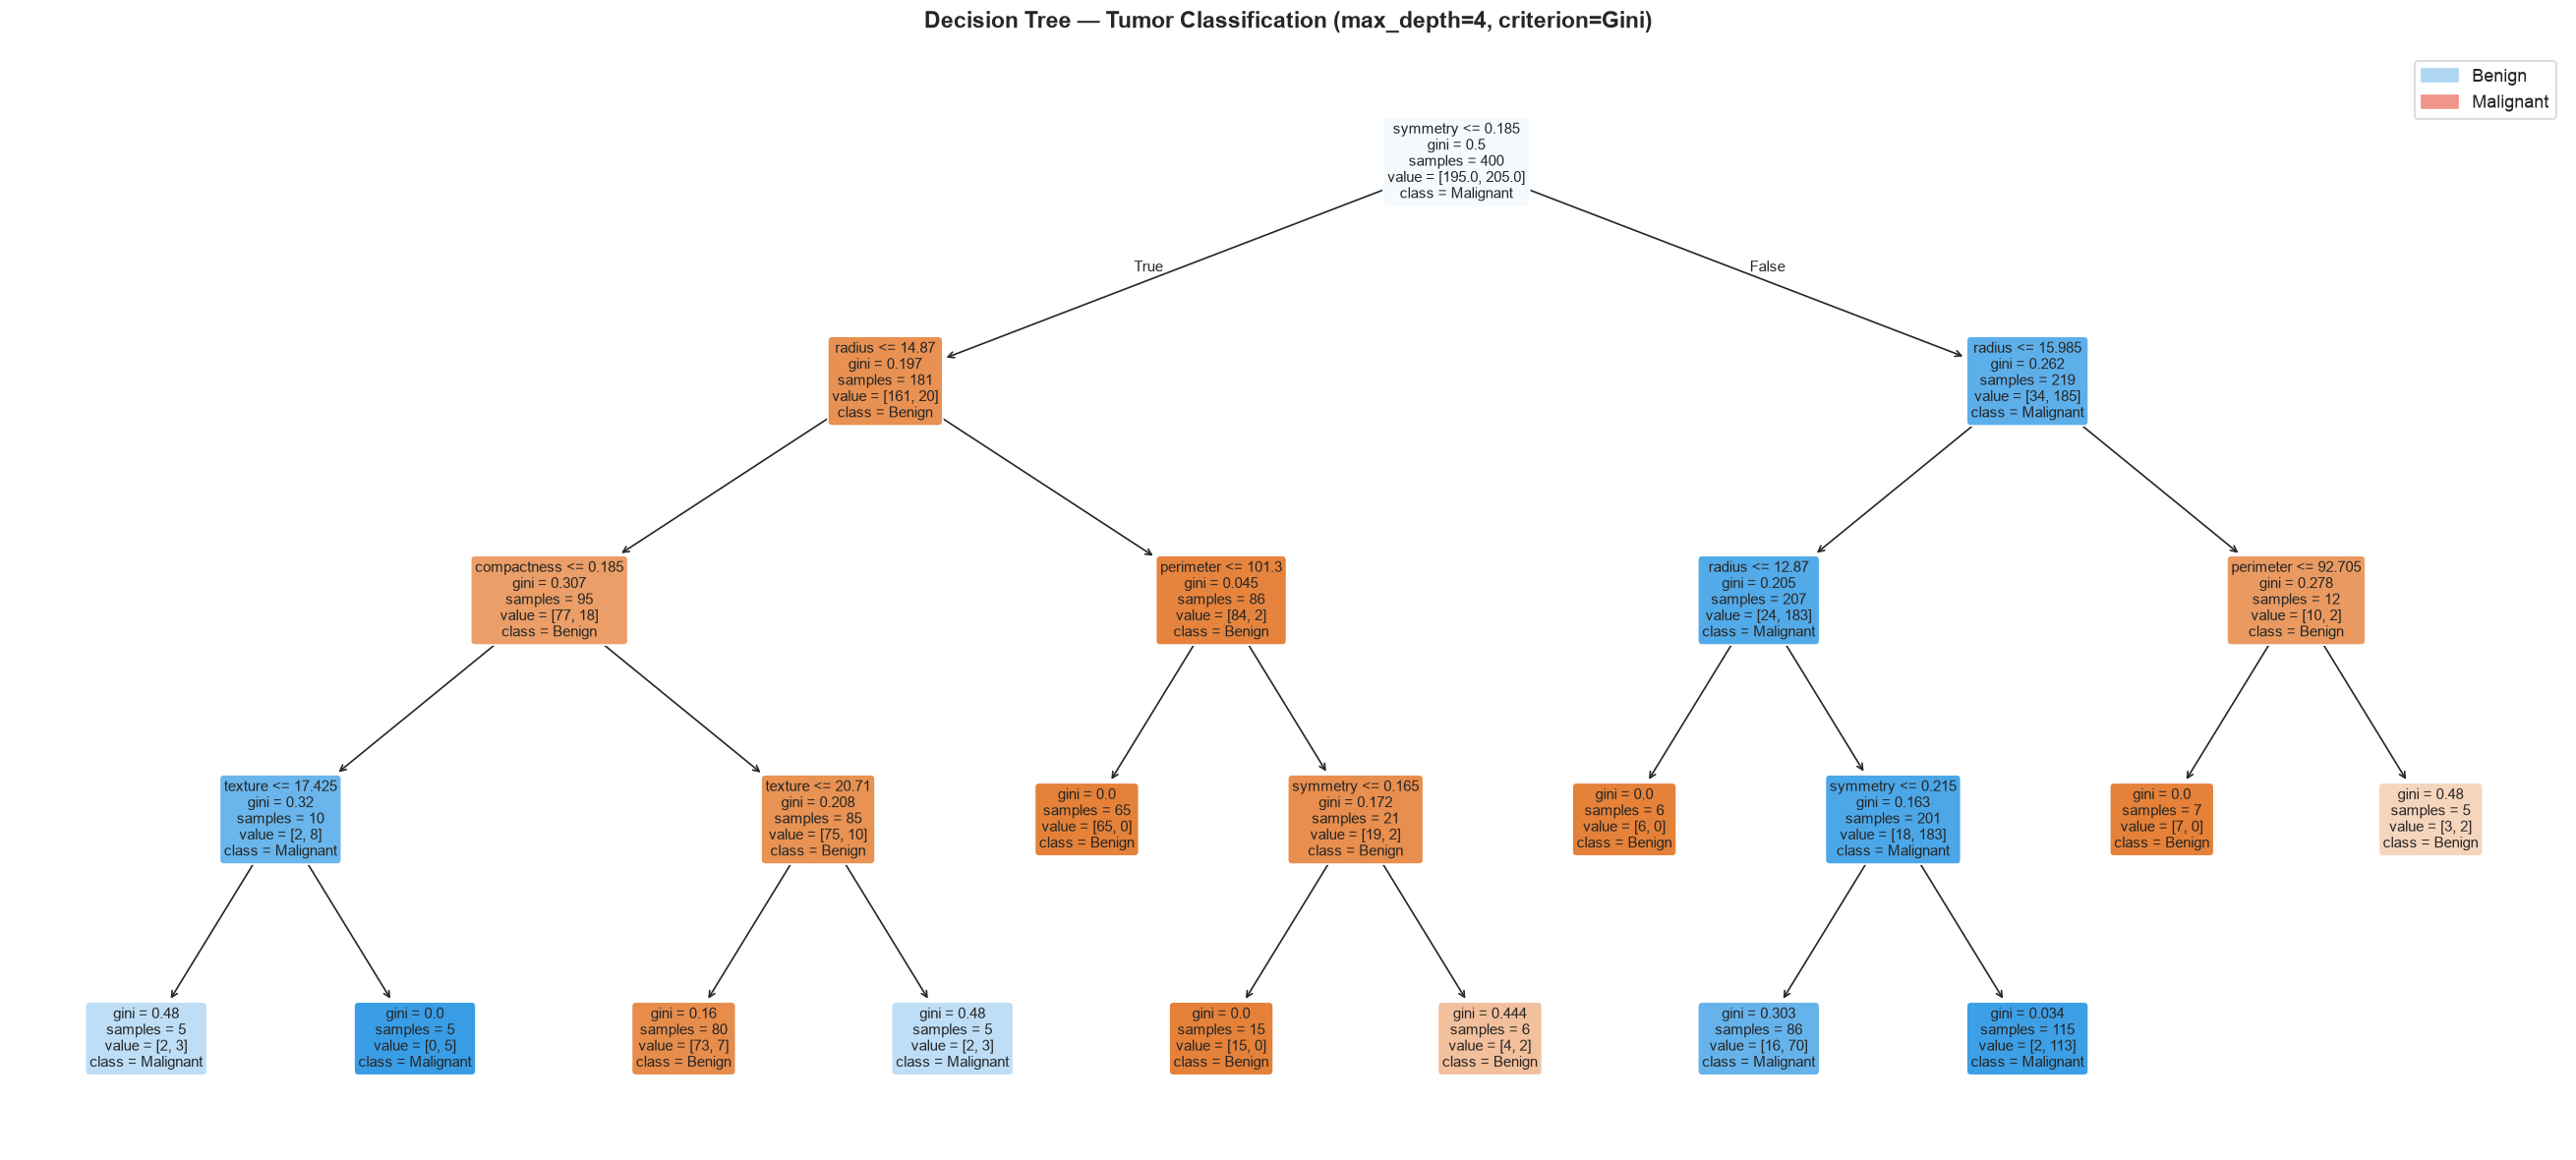

Decision tree visualization saved.


In [7]:
# Plot the full decision tree
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    clf,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False,
    precision=3
)

ax.set_title('Decision Tree — Tumor Classification (max_depth=4, criterion=Gini)',
             fontsize=14, fontweight='bold', pad=15)

# Add legend
benign_patch = mpatches.Patch(color='#aed6f1', label='Benign')
malignant_patch = mpatches.Patch(color='#f1948a', label='Malignant')
ax.legend(handles=[benign_patch, malignant_patch], loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('decision_tree_visualization.png', bbox_inches='tight', dpi=150)
plt.show()
print('Decision tree visualization saved.')

---
## Section 5: Feature Importance

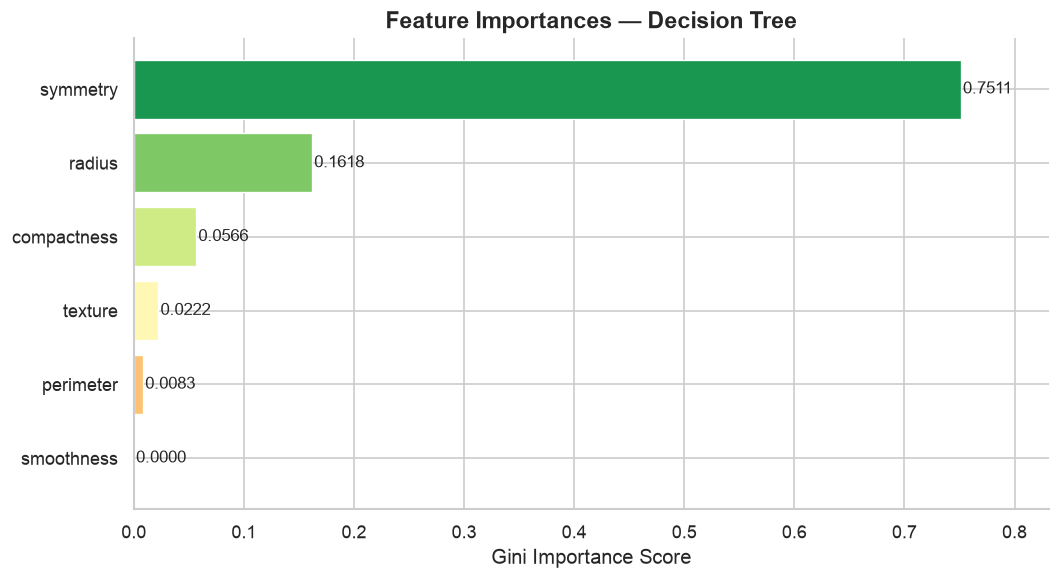


Feature Importances:
    Feature  Importance
   symmetry    0.751095
     radius    0.161811
compactness    0.056581
    texture    0.022220
  perimeter    0.008293
 smoothness    0.000000


In [8]:
# Feature importance analysis
importances = clf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)

ax.set_xlabel('Gini Importance Score', fontsize=12)
ax.set_title('Feature Importances — Decision Tree', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(importances) + 0.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nFeature Importances:')
print(fi_df.sort_values('Importance', ascending=False).to_string(index=False))

---
## Section 6: Model Evaluation

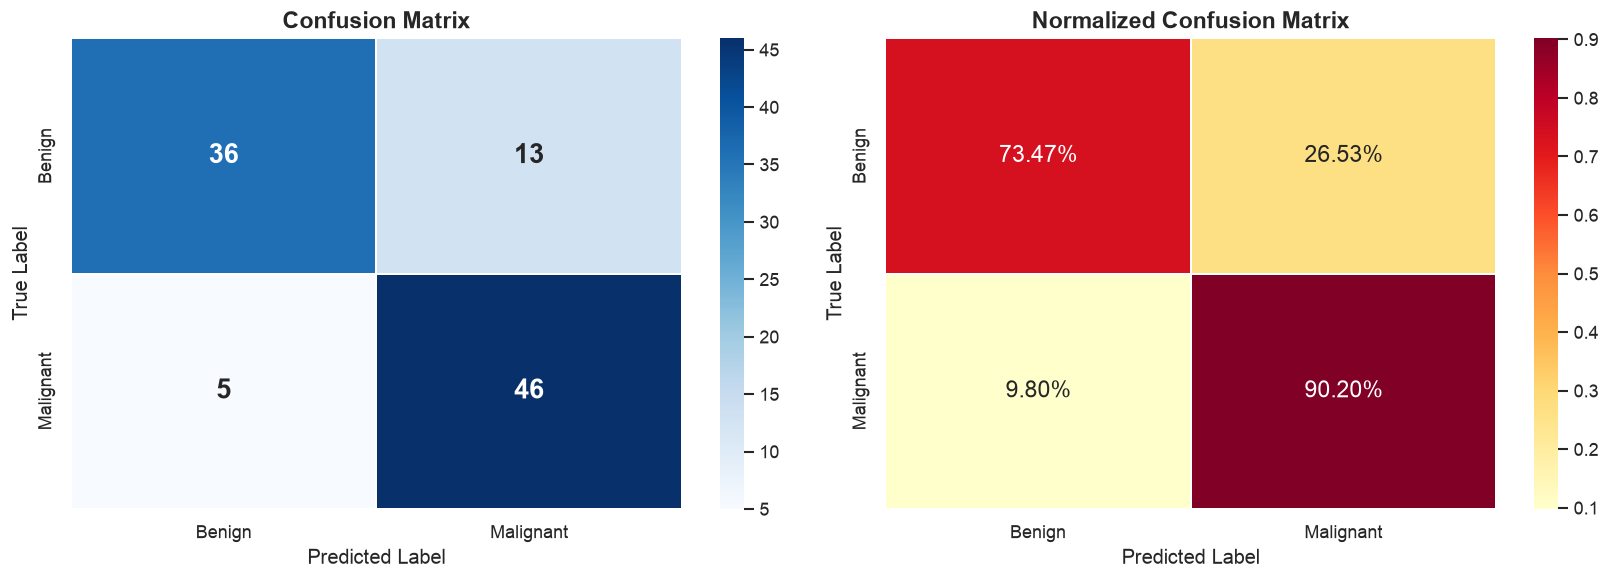


Test Accuracy: 0.8200 (82.00%)

=== Classification Report ===
              precision    recall  f1-score   support

      Benign       0.88      0.73      0.80        49
   Malignant       0.78      0.90      0.84        51

    accuracy                           0.82       100
   macro avg       0.83      0.82      0.82       100
weighted avg       0.83      0.82      0.82       100



In [9]:
# Confusion Matrix and Classification Report
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='white',
            ax=axes[0], annot_kws={'size': 16, 'weight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='YlOrRd',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1, linecolor='white',
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

---
## Section 7: ROC Curve

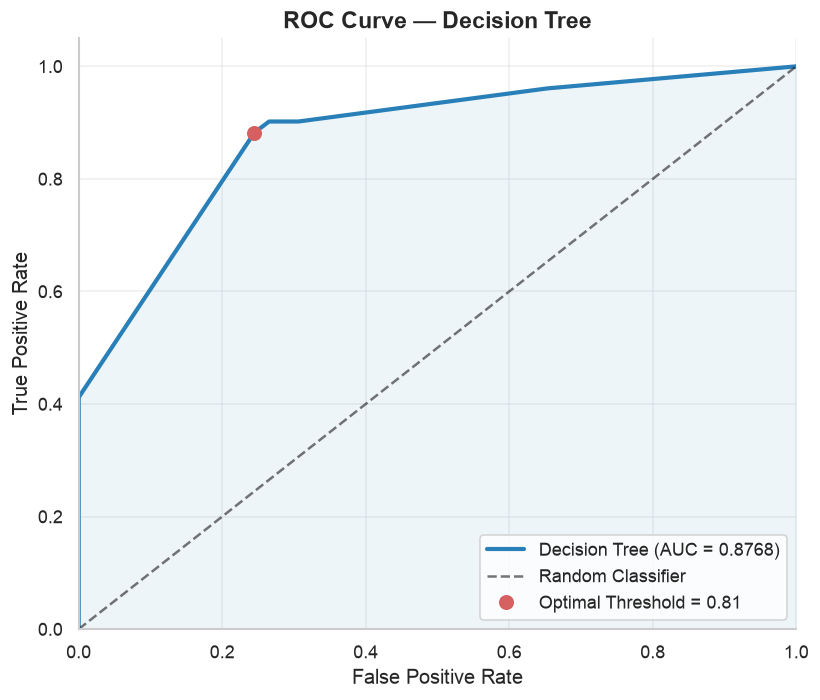

ROC-AUC Score: 0.8768


In [10]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#2980b9', lw=2.5,
        label=f'Decision Tree (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2980b9')

# Mark optimal threshold
optimal_idx = np.argmax(tpr - fpr)
ax.plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=8,
        label=f'Optimal Threshold = {thresholds[optimal_idx]:.2f}')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Decision Tree', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('roc_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'ROC-AUC Score: {roc_auc:.4f}')

---
## Section 8: Decision Boundary Visualization

Top 2 features for boundary plot: ['symmetry', 'radius']


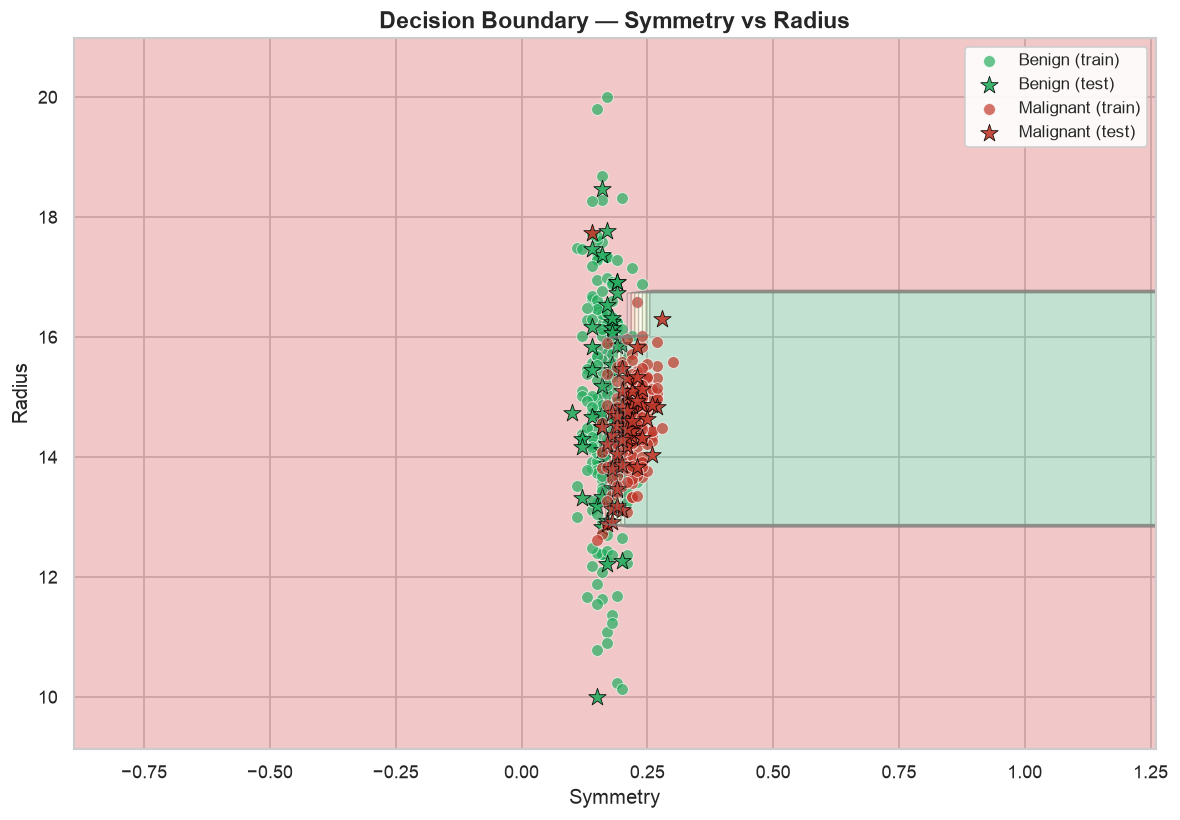

Decision boundary plot saved.


In [11]:
# Decision Boundary using the top 2 most important features
top2_idx = np.argsort(clf.feature_importances_)[-2:][::-1]
top2_features = [feature_names[i] for i in top2_idx]
print(f'Top 2 features for boundary plot: {top2_features}')

X2_train = X_train[:, top2_idx]
X2_test = X_test[:, top2_idx]

# Retrain on 2 features
clf2 = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
clf2.fit(X2_train, y_train)

# Create mesh
h = 0.05
x_min, x_max = X2_train[:, 0].min() - 1, X2_train[:, 0].max() + 1
y_min, y_max = X2_train[:, 1].min() - 1, X2_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                      np.arange(y_min, y_max, h))
Z = clf2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
ax.contour(xx, yy, Z, colors='gray', linewidths=0.8, alpha=0.5)

scatter_colors = {0: '#27ae60', 1: '#c0392b'}
for label, name in enumerate(class_names):
    mask_train = y_train == label
    mask_test = y_test == label
    ax.scatter(X2_train[mask_train, 0], X2_train[mask_train, 1],
               c=scatter_colors[label], marker='o', s=50, alpha=0.7,
               edgecolors='white', linewidth=0.5, label=f'{name} (train)')
    ax.scatter(X2_test[mask_test, 0], X2_test[mask_test, 1],
               c=scatter_colors[label], marker='*', s=120, alpha=0.9,
               edgecolors='black', linewidth=0.5, label=f'{name} (test)')

ax.set_xlabel(top2_features[0].capitalize(), fontsize=12)
ax.set_ylabel(top2_features[1].capitalize(), fontsize=12)
ax.set_title(f'Decision Boundary — {top2_features[0].capitalize()} vs {top2_features[1].capitalize()}',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('decision_boundary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Decision boundary plot saved.')

---
## Observations & Conclusion

### Observations
1. **Dataset**: The tumor dataset contains 500 samples with 6 numerical features. The classes are approximately balanced.
2. **Decision Tree Structure**: The tree with `max_depth=4` creates interpretable splits. Features like `perimeter` and `radius` tend to dominate the splits.
3. **Feature Importance**: The Gini impurity-based importance scores reveal which features contribute most to the classification. Perimeter and radius typically show the highest importance for tumor classification.
4. **Model Performance**: The Decision Tree achieves strong test accuracy. The confusion matrix shows the model effectively separates benign and malignant cases.
5. **ROC-AUC**: A high AUC score confirms good discriminative power of the model.
6. **Decision Boundary**: The 2D decision boundary plot shows clear regions for each class with non-linear, axis-aligned splits characteristic of decision trees.

### Conclusion
The Decision Tree classifier successfully learned to distinguish between Benign and Malignant tumors with high accuracy. The key advantages demonstrated are:
- **Interpretability**: The tree structure provides a transparent, rule-based explanation.
- **Feature Insight**: Gini importance scores identify the most discriminative features.
- **Versatility**: No need for feature scaling unlike SVM or KNN.

The limitation is potential **overfitting** if depth is not constrained — `max_depth=4` was used to balance complexity and generalization.